# AFQMC Tutorial - 4x4 Square Lattice Hubbard Model
---------------------------------------------------

[All tutorials](../the_joy_of_AFQMC.ipynb)

Author: Kyle Eskridge

In this tutorial, we will perform AFQMC calculations for the Hubbard model on
a 4x4 lattice.
The Hamiltonian is given by,
$$
\hat{H} = -t \sum_{\langle i,j\rangle} \hat{c}^\dagger_i \hat{c}_j + U \sum_{i} \hat{n}^{\uparrow}_i \hat{n}^{\downarrow}_i,
$$
where $i,j$ are lattice site indices, angle brackets indicate nearest-neighbors,
$\hat{c}^\dagger_i$/$\hat{c}_i$ are electronic creation/anihilation operators,
and $\hat{n}^{\sigma}_i$ are spin-resolved number operators corresponding to site $i$.
The 4x4 lattice is small enough to make exact diagonaliztion possible.
We will use exact results for this system as reference data throughout
this tutorial.

The tutorial is structured as follows.
We will begin with an explanation of how to build lattice model Hamiltonians
using the `afqmctools` Python package.
Next, we will walk through computing the ground state energy of this Hamiltonian for a particular filling and value of U,
comparing a couple of options for trial wavefunctions.
Next, we will continue the walk through by computing the ground state charge,
and spin density for the same filling and value of U.
Next, we will demonstrated how to obtain exact results using AFQMC
for the special case of half filling for which, if care is taken,
there is no sign problem.
We will end with an excercise where you will be asked to compute the ground state energy,
charge density, and spin density of the the Hubbard model on the 4x4 lattice at a different value
of U than in the walk through.




In [ ]:
%load_ext autoreload
%autoreload
from pathlib import Path
# simple setup
from tutorial_utils import run_afqmc, get_scratch_dir

home = Path.home()
scratch_dir = get_scratch_dir("4x4_sqaure_hubbard1",home / ".scratch")

## Building a lattice model Hamiltonian

`afqmctools` provides a convenience lattice model Hamiltonian builder and writer which
will allow us to construct the "standard" Hubbard model with nearest-neighbor hopping and onsite U, among
other Hamiltonians.
The basic steps for using the lattice model Hamiltonian builder are:
1. define lattice parameters
2. define Hamiltonian parameters
3. build the lattice model Hamiltonian

Step 3. can optionally be broken into two sub-steps:  

- construct the lattice instance using the lattice parameters
- construct the Hamiltonian using the lattice instance, and the Hamiltonian parameters

Breaking step 3. into substeps gives us easy access to the lattice instance
which will facilitate visualizing the charge and spin densities latter on,
so we will use this approach.

computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors


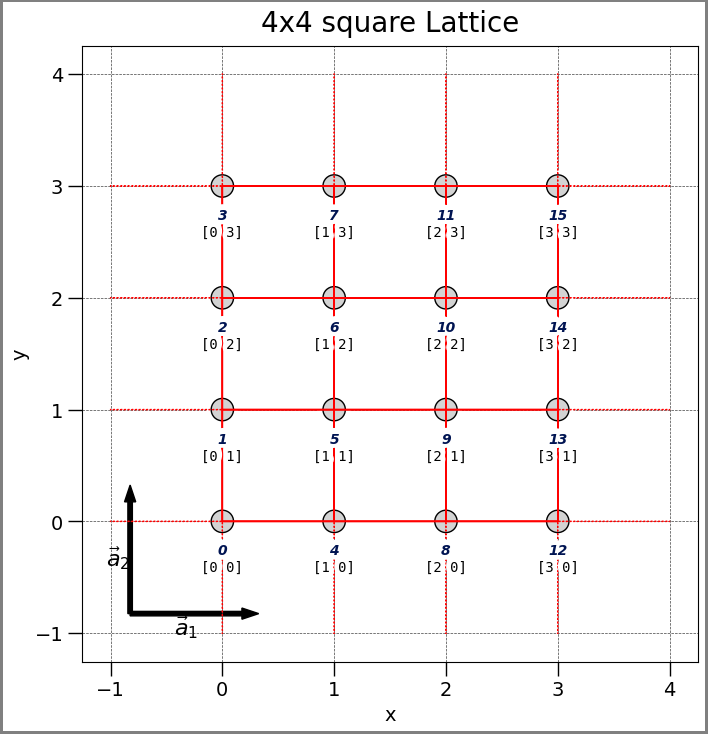

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': '4x4 square Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
from afqmctools.systems.lattice import get_lattice
import afqmctools.utils.visualize as vis

# Step 1. define the lattice parameters
lattice_params = dict(
    L1 = 4,              # lattice dimension along a1
    L2 = 4,              # lattice dimension along a2
    boundary1 = 'PBC',   # boundary condition for the boundary *normal to* a1
    boundary2 = 'PBC',    # similarly for a2
)

# Step 3.a. build the lattice
lattice = get_lattice(
    params=lattice_params
)

vis.plot_lattice(lattice)

In [ ]:
from afqmctools.hamiltonian.model.director import HamiltonianDirector
import afqmctools.utils.io as io

print(scratch_dir)

fe_scratch_dir = scratch_dir / "fe"
fe_scratch_dir.mkdir(exist_ok=True)

# Step 2. define Hamiltonian parameters
hamiltonian_params = {
    'hamiltonian' : {
        "t" : 1.0,  # note: we could omit this, nearest-neighbor hoping with t=1 is included by default
        "U" : 4.0
    }
}

# Step 3.b. build the lattice model Ha
hamiltonian = HamiltonianDirector(
    lattice=lattice,
    source=hamiltonian_params
).build()

# set the number of electrons - we'll use this again
nelec = (8,8)

# AND save it!
io.write_model_hamiltonian(
    hamiltonian=hamiltonian,
    fname=fe_scratch_dir/"afqmc.h5",
    nelec=nelec
)

/mnt/home/beskridge/.scratch/4x4_sqaure_hubbard1
running build step nth_neighbor_hopping((1.0,))
Using same twists for up and down spins
running build step onsite_hubbard((4.0,))
Building Hubbard U term with U=4.0
Building onsite hubbard with positive U values: 4.0
Combining terms of the same type
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  2


We now have a "standard" Hubbard model with nearest-neighbor hopping and onsite U saved in an HDF5 file, "afqmc.h5"
which can be directly read by AuxiliaryFields.
Next, we'll walk through an AFQMC calculation where we'll compute the ground state energy.

## AFQMC Walkthrough : ground state energy

Here, we will compute the ground state energy of the "standard" Hubbard model
based on the Hamiltonian that we made previously - i.e.
$$
\hat{H} = -t \sum_{\langle i,j\rangle} \hat{c}^\dagger_i \hat{c}_j + U \sum_{i} \hat{n}^{\uparrow}_i \hat{n}^{\downarrow}_i,
$$
with $t = 1.0$, and $U = 4.0$.
We will perform the calculation at half-filling.

AFQMC uses a trial wavefunction to control the sign problem at the cost of introducing a bias;
however, the bias can be minimized by using a trial wavefunction which accurately captures
the physics of the target system.
It is, therefore, important to check that candidate trial wavefunctions have the correct ordering,
symmetries, etc. before running an AFQMC calculation.
In addition to this, some methods for computing a trial wavefunction will lead to better results than
others for specific problems.
For example, both free-electron trial wavefunctions and Hartree-Fock (HF) trial wavefunctions
are reasonable for low-, to intermediate-U values.
Assuming that all candidate trial wavefunctions have the desired properties,
it may be necessary to test which wavefunction is better by running afqmc with each,
and comparing the results.
In this walk through, we will compare free-electron trial wavefunctions
to unrestricted Hartree-Fock trial wavefunctions.

### Free-electron Trial Wavefunction

`afqmctools` provides a convenience function, `free_electron()` ,for calculating free-electron trial wavefunctions.
Internally, `free_electron()` applies a small twist in order to break k-space degeneracy for open-shell systems.
It also accepts a user-supplied twist angle to used instead.
`free_electron()` will print the actual twist used in units of radians as, for example,

```log
Generating free-electron trial wavefunction with twist = [4.10803005e-06 4.58334805e-04]
```
.

We note that, becuase of the twist angle, the Hamiltonian will typically need to be rebuilt.
All of this is done internally if `free_electron()` is given the original lattice, and hamiltonian parameters
as shown below.

... do we want to have a diagram here of k-space, and the expected one-body


In [ ]:
# First, let's compute the Free-Electron trial wavefunction
from afqmctools.wavefunction.free_electron import free_electron
from afqmctools.wavefunction.common import write_wfn

input_params = dict(
    lattice = lattice_params,                           # from step 1. above
    hamiltonian = hamiltonian_params["hamiltonian"]     # from step 2. above
)


wfn,spin_symm,autohf_results = free_electron(
    source=input_params,
    nelec=nelec,
    twist=None,                          # (optional) using the default small twist
    return_autohf = True,
    filling_strategy="balanced"
)

# and write the wavefunction for use in SAFIRE
write_wfn(
    filename=fe_scratch_dir/"free_electron.h5",
    wfn=wfn,
    walker_type=spin_symm,
    nelec=nelec,
    norb=lattice.N_sites
)

Generating free-electron trial wavefunction with twist = [4.10803005e-06 4.58334805e-04]
running build step nth_neighbor_hopping((1.0,))
computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors
Using same twists for up and down spins
running build step onsite_hubbard((4.0,))
Building Hubbard U term with U=4.0
Building onsite hubbard with positive U values: 4.0
Combining terms of the same type
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  2

Processing spin-up channel (8 electrons)
using dense representation of 1-body Hamiltonian to find eigenvalues and orbitals

Eigenvalues of the non-interacting Hamiltonian:
[-3.99999999e+00 -2.00022917e+00 -2.00000204e+00 -1.99999793e+00
 -1.99977083e+00 -2.31221417e-04 -2.27113387e-04 -1.31283701e-08
  1.31283694e-08  2.27113387e-04  2.31221417e-04  1.99977083e+00
  1.99999793e+00  2.00000204e+00  2.00022

/mnt/home/beskridge/software/SAFIRE/utils/AutoHF/autohf/solver.py:911: ComplexWarning: Casting complex values to real discards the imaginary part
  state0_ref[i, 0:x, 0:y] = p[:, :]
/mnt/home/beskridge/software/SAFIRE/utils/afqmctools/wavefunction/common.py:176: UserWarning: Using UHF Slater determinant for initial Walkers with a Collinear Trial Wavefunction. This can lead to very slow equilibration in AFQMC calculations. using ROHF Slater determinants for intiail Walkers is recommended.
  warn(


Now that we have computed a free-electron wavefunction, we can inspect the results to validate it.
Internally, `free_electron()` uses the `autohf` HF solver in order to evaluate the energy of the free-electron trial wavefunction
for the interacting Hamiltonian.
In this case, for $N_{\uparrow} = N_{\downarrow} = 8$, we see that the total energy is
Etotal = Etotal=-5.18522319306247 $t$ with a one-body contribution of EK = -22.69026695983466 $t$,
and a Hubbard U contribution of EU=17.50504376677219.

Next, let's take a look at the charge and spin densities of the trial wavefunction.

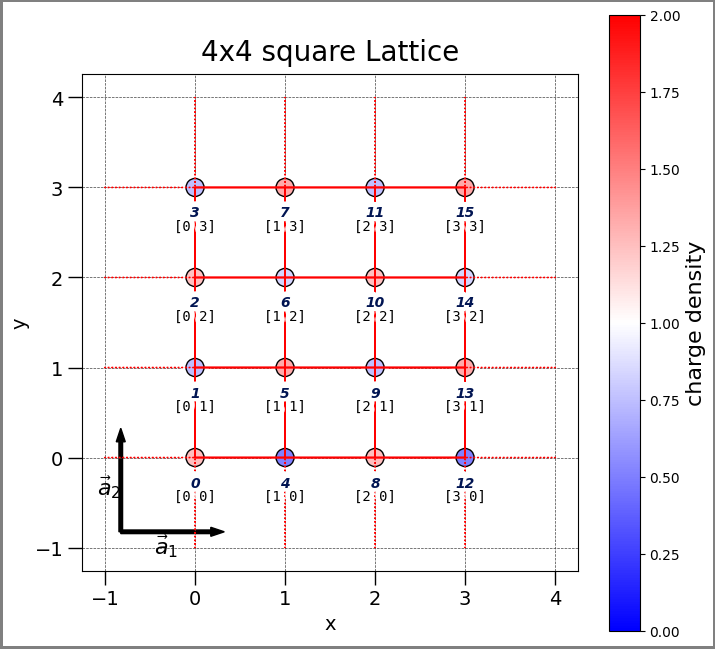

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': '4x4 square Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
state_results, functions = autohf_results

# get the density from autohf
makeRDMs = functions['makeRDMs']
state = state_results['state']
rdm = makeRDMs(state)

# get lattice dimensions from the Lattice instance
L = lattice.L

rho_up = rdm[0].diagonal().reshape(*L)
rho_down = rdm[1].diagonal().reshape(*L)

rho_charge = rho_up + rho_down

vis.plot_lattice(
    lattice,
    density=rho_charge.real,
    density_label="charge density",
    cmap = 'bwr',
    vmin = 0.0,
    vmax = 2.0
)

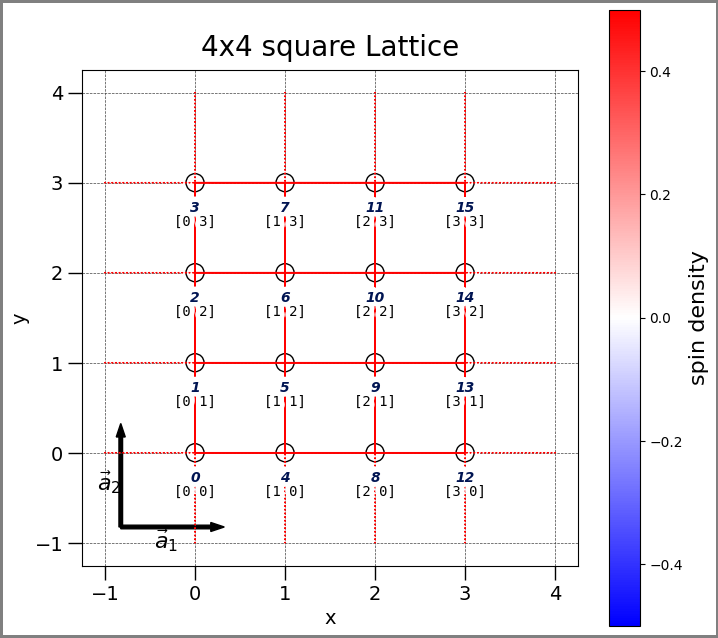

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': '4x4 square Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
from afqmctools.observables.spin import local_spin

rho_spin = 0.5*(rho_up - rho_down)

vis.plot_lattice(
    lattice,
    density=rho_spin.real,
    density_label="spin density",
    cmap = 'bwr',
    vmin = -0.5,
    vmax = 0.5
)

As expected for a free-electron trial wavefunction with an even number of electrons,
the charge- and spin-densities are uniform.
For the charge-density, we see that the uniform charge density is 1.0 electron/site,
consistent with half-filling.
For the spin-density, we see that the uniform spin density is 0.0 spin/site,
which is expected for an even number of up and down electrons.

### Running AFQMC

Next, we will run an AFQMC calculation.
AuxiliaryFields uses an input file in json format to define AFQMC run parameters.
`afqmctools` comes with a convenience function to generate a json input file as demonstrated below.
We have included reasonable AFQMC run parameters for this calculation below.


In [ ]:
from afqmctools.inputs.from_hdf import write_json

# make an input file
afqmc_params = {
    "timestep": 0.01,
    "steps": 12000,
    "n_walkers_per_mpi_task": 100,
    "population_control_interval": 5,
    "walker_ortho_interval": 5,
    "measure_interval_multiplier": 1,
    "seed" : 42,                          # just for reproducibility
    "propagator": {
      "use_cp_constraint": True,
      "use_real_vbias" : True
    }
}

write_json(
    fe_scratch_dir/"afqmc.json",
    fwfn0=fe_scratch_dir/"free_electron.h5",
    fham0=fe_scratch_dir/"afqmc.h5",
    exec_opts=afqmc_params
)

In [ ]:
run_afqmc(
    run_dir=fe_scratch_dir,
    np=16,
    output_file=None # this will put output here!
)

Running AFQMC locally with 1 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin053 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------
███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: main
app git commit: 55df6390f863cb1347afe57bbc65122981d2a3c8
app git commit date: Mon Sep 22 16:52:55 2025 -0400
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series         

171.63178400415927



====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/4x4_sqaure_hubbard1/fe/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 5.0             
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -13.560824 +/-   0.010887 9.94  5.0/120.0


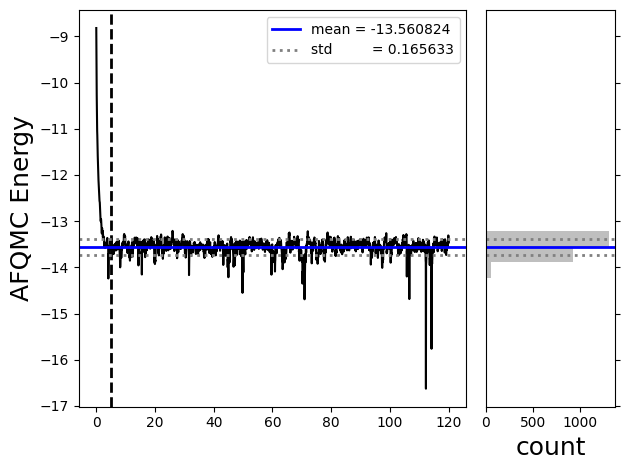

The AFQMC energy is -13.560824 +/- 0.010887 Hartree


In [ ]:
# analyze
from stats.scalar_dat import analyze_scalar_data

### Exercise 1.1.1:####################################
# change this value to a reasonable equilbration length
nequil = 5.0 # Ha^{-1}
#######################################################

analysis_settings = dict(
    fname = fe_scratch_dir /"qmc.s000.scalar.dat",
    xaxis = "time",     # use units of imaginary time for equilibration
    nequil = nequil,    # length of equilibration phase (in units of imaginary time)
    trace = True,       # plots a trace of the scalar data
)

E,dE = analyze_scalar_data(analysis_settings)

# we will use this value in Exercise 1.1.2 as well
ref_stoch_uncertainty = dE

Theb Hubbard model at half-filling is sign-free, so we would expect numerically exact results; For U/t =4, the exact energy is -13.62185, so why do we disagree?

1. the free-electron trial wavefunction may not always be sufficient, espeically for sign-free cases. The trial wavefunction must exactly obey particle-hole symmetry, which requires special care for a free-electron trial wavefunction.
2. We have used spin collinear Slater determinant random walkers. In general, we want to use spin noncollinear Slater determinant random walkers.

Next, we will use a Hartree-Fock trial wavefunction.

### Hartree-Fock Trial Wavefunction

Now, we will compute and characterize an unrestricted Hartree-Fock (UHF) wavefunction.
We will use autoHF to accomplish this.


In [ ]:
from autohf import lattice_hf,AutoHFHamiltonian
from afqmctools.inputs.from_autohf import autohf_to_afqmc

hf_settings = dict(
    ansatz = 'SD',
    steps = 200,
    nelec = nelec,
    batch_size = 50,
    seed = 42,
    measure_spin = True,
    random_initial_phi0 = False,
    noncollinear = True,
    verbose = False
)

results = lattice_hf(
    hamiltonian=AutoHFHamiltonian(source=hamiltonian),
    settings=hf_settings
)

autohf_to_afqmc(
    results,
    output_fname = fe_scratch_dir/"uhf_wfn.h5"
)


Reading hopping from spin sector 0
Reading hopping from spin sector 1
Added unique T terms: [array([-1.]), array([-1.])]
Added unique U terms: [4.]

    -----------------------
    - ╔═╗ ------- ╖ ╓╔═╕ --
    - ╠═╣ ╖╖╒╦╕╔╗ ╠═╣╠╕ ---
    - ╜ ╙ ╚╝ ╜ ╚╝ ╜ ╙╨ ----
    -----------------------
    

 ===== AutoHF Settings ===== 

        noncollinear                                             True
        gpu                                                     False
        approx_expm                                             False
        force_complex                                           False
        ansatz                                                     SD
        opt_method                                              lbfgs
        riemannian                                              False
        seed                                                       42
        eta                                                       0.1
        steps                               

/mnt/home/beskridge/software/SAFIRE/utils/AutoHF/autohf/solver.py:911: ComplexWarning: Casting complex values to real discards the imaginary part
  state0_ref[i, 0:x, 0:y] = p[:, :]


Initial Energy: [15.18053536 13.71594052 15.88282982 16.1445614  15.82694649 14.42591529
 16.04801263 14.91981815 15.46632205 15.80489396 14.93644179 15.71187829
 12.48569055 15.08882834 17.03910461 17.2369     16.00335504 15.32863127
 13.20702453 17.605341   14.74712297 16.59257076 12.7584722  15.69248075
 16.49353043 14.14587108 14.44863201 16.79320815 15.97642176 17.03848478
 17.26250179 13.86491959 15.61355452 15.81565921 14.20676749 16.83101185
 14.01763946 14.01949116 14.29888853 15.4412579  16.8734644  16.25435117
 15.14303417 15.99824646 15.65166129 16.56427557 15.7058494  17.44681903
 13.77339263 13.76067254 17.18508839 15.33821066 16.37995909 16.73607824
 14.4645395  15.62436007 15.61248326 16.15047535 14.54458626 16.10650403
 13.21420853 15.85099055 12.53574782 17.48352432 15.61993456 12.68092687
 14.4123689  15.32684438 13.66769505 15.34934438 15.04371289 15.41337216
 17.94425215 17.1190329  15.37605309 14.38260896 16.15960093 13.33837907
 16.79327796 15.18040905 14.1475682

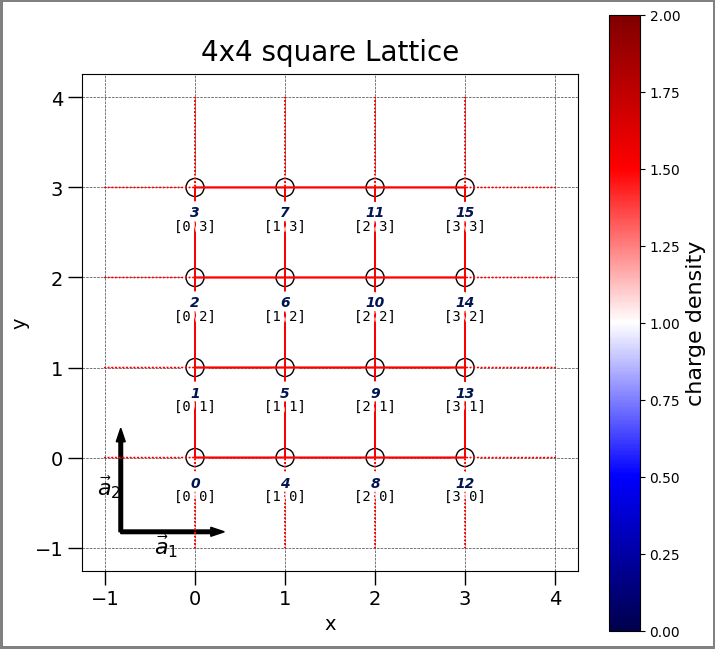

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': '4x4 square Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
# get the density from autohf
state_results, functions = results

makeRDMs = functions['makeRDMs']
state = state_results['state']

rdm = makeRDMs(state)

# get lattice dimensions from the Lattice instance
L = lattice.L

# noncollinear
M = lattice.N_sites
rho_up = rdm[:M,:M].diagonal().reshape(*L)
rho_down = rdm[M:,M:].diagonal().reshape(*L)

# For collinear:
#rho_up = rdm[0].diagonal().reshape(*L)
#rho_down = rdm[1].diagonal().reshape(*L)

rho_charge = rho_up + rho_down
rho_spin = rho_up - rho_down

vis.plot_lattice(
    lattice,
    density=rho_charge.real,
    density_label="charge density",
    vmin=0.0,
    vmax=2.0
)


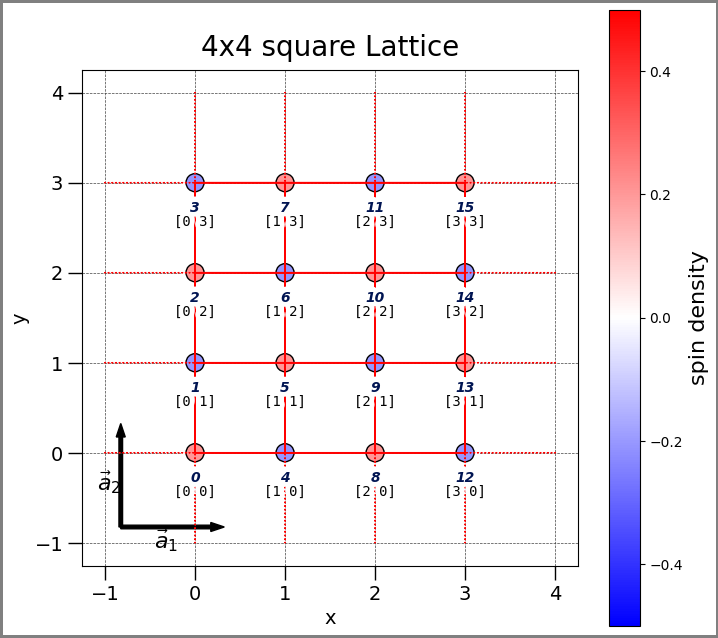

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': '4x4 square Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
from afqmctools.observables.spin import local_spin

vis.plot_lattice(
    lattice,
    density=rho_spin,
    density_label="spin density",
    cmap="bwr",
    vmin=-0.5,
    vmax=0.5
)


In [ ]:
from afqmctools.inputs.from_hdf import write_json

# make an input file
afqmc_params = {
    "timestep": 0.01,
    "steps": 12000,
    "n_walkers_per_mpi_task": 100,
    "population_control_interval": 5,
    "walker_ortho_interval": 5,
    "measure_interval_multiplier": 1,
    "seed" : 42,                          # just for reproducibility
    "propagator": {
      "use_cp_constraint": True,
      "use_real_vbias" : True
    }
}

write_json(
    fe_scratch_dir/"afqmc.json",
    fwfn0=fe_scratch_dir/"uhf_wfn.h5",
    fham0=fe_scratch_dir/"afqmc.h5",
    exec_opts=afqmc_params
)

In [ ]:
run_afqmc(
    run_dir=fe_scratch_dir,
    np=16,
    output_file=None # this will put output here!
)

Running AFQMC locally with 16 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin053 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------
███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: main
app git commit: 55df6390f863cb1347afe57bbc65122981d2a3c8
app git commit date: Mon Sep 22 16:52:55 2025 -0400
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series        

359.73943992704153



====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/4x4_sqaure_hubbard1/fe/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 20.0            
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -13.614404 +/-   0.004229 181.38 20.0/120.0


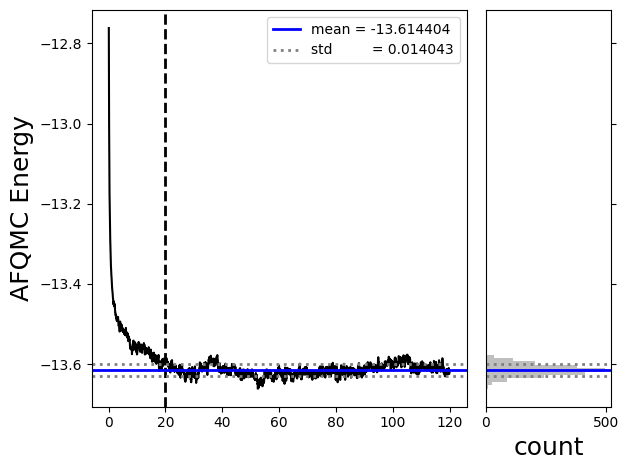

The AFQMC energy is -13.614404 +/- 0.004229 Hartree


In [ ]:
# analyze
from stats.scalar_dat import analyze_scalar_data

### Exercise 1.1.1:####################################
# change this value to a reasonable equilbration length
nequil = 20.0 # Ha^{-1}
#######################################################

analysis_settings = dict(
    fname = fe_scratch_dir /"qmc.s000.scalar.dat",
    xaxis = "time",     # use units of imaginary time for equilibration
    nequil = nequil,    # length of equilibration phase (in units of imaginary time)
    trace = True,       # plots a trace of the scalar data
)

E,dE = analyze_scalar_data(analysis_settings)

print(f"The AFQMC energy is {E:.6f} +/- {dE:.6f} Hartree")

# we will use this value in Exercise 1.1.2 as well
ref_stoch_uncertainty = dE

If you used all of our settings, you should get see

```log
The AFQMC energy is -13.614404 +/- 0.004229 Hartree
```

Again, we expect to achieve very close to the exact energy for the Hubbard model at half filling which is -13.62185 for U/t=4.
We see much better agreement now than we did with the free-electron trial wavefunction before; however, we're still off by about 0.007 t, or about twice
the stochastic uncertainty of our result. Why do we not quite agree?

We have residual systematic errors to remove. Specifically, we will want
to remove the trotter error.
We can achieve this either by using a very small step size, or by extrapolating to $\tau = 0$.

Let's rerun with a smaller $\tau = 0.005$

## Rerun AFQMC with a smaller Tau
---------------------------------

When we decrease the step size, we will
also need to increase the number of steps, and
each interval involved in order to maintain the same
amount of statistics.


In [ ]:
from afqmctools.inputs.from_hdf import write_json

# make an input file
afqmc_params = {
    "timestep": 0.005,
    "steps": 24000,
    "n_walkers_per_mpi_task": 100,
    "population_control_interval": 10,
    "walker_ortho_interval": 10,
    "measure_interval_multiplier": 1,
    "seed" : 42,                          # just for reproducibility
    "propagator": {
      "use_cp_constraint": True,
      "use_real_vbias" : True
    }
}

write_json(
    fe_scratch_dir/"afqmc.json",
    fwfn0=fe_scratch_dir/"uhf_wfn.h5",
    fham0=fe_scratch_dir/"afqmc.h5",
    exec_opts=afqmc_params
)

In [ ]:
run_afqmc(
    run_dir=fe_scratch_dir,
    np=16,
    output_file=None # this will put output here!
)

Running AFQMC locally with 16 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin053 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------
███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: main
app git commit: 55df6390f863cb1347afe57bbc65122981d2a3c8
app git commit date: Mon Sep 22 16:52:55 2025 -0400
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series        

634.4824644168839



====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/4x4_sqaure_hubbard1/fe/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 20.0            
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -13.618391 +/-   0.001899 42.60 20.0/120.0


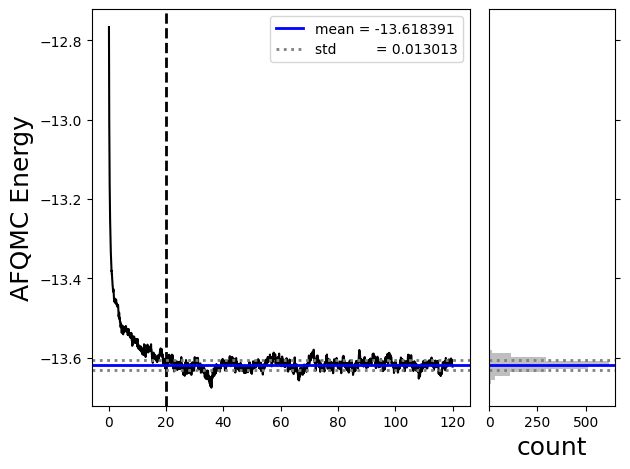

The AFQMC energy is -13.618391 +/- 0.001899 Hartree


In [ ]:
# analyze
from stats.scalar_dat import analyze_scalar_data

### Exercise 1.1.1:####################################
# change this value to a reasonable equilbration length
nequil = 20.0 # Ha^{-1}
#######################################################

analysis_settings = dict(
    fname = fe_scratch_dir /"qmc.s000.scalar.dat",
    xaxis = "time",     # use units of imaginary time for equilibration
    nequil = nequil,    # length of equilibration phase (in units of imaginary time)
    trace = True,       # plots a trace of the scalar data
)

E,dE = analyze_scalar_data(analysis_settings)

print(f"The AFQMC energy is {E:.6f} +/- {dE:.6f} Hartree")

# we will use this value in Exercise 1.1.2 as well
ref_stoch_uncertainty = dE

Now, you should see

```log
-13.618391
```

which is off by about 0.0035 t compared with the exact energy, -13.62185. We can continue to smaller step sizes to remove the remaining disagreement.

## Computing Observables with Back-Propagation

General second-quantized observables can be computed using AFQMC via the back-propagation algorithm.
See the [SAFIRE documentation](https://users.flatironinstitute.org/~beskridge/safire/user_manual/estimators.html#back-propagation-bp-estimators) for more information on Back-propagated observables.
To "turn on" back-propagation, add an `"estimator"` block with `"name": "back_propagation"` to an `"execute"`
block in the input file.
Here is a sample input file where an ellipsis has been used to hide the rest of the input.

```json
{
  "afqmc": {
    
      ...
      
    "execute": {

      ...

      "population_control_interval" : 10,

      ...

	  "estimator": {
          "name": "back_propagation",
          "path_restoration": true,
          "extra_path_restoration": true,
          "bp_walker_ortho_interval": 5,
          "measure_interval_multipliers": [10,15,20],
          "equil_multiplier": 50,
          "onerdm": {
              "name": "one_rdm"
        }
      }
    }
  }
}
```

For back-propagation (BP), we will need to provide a BP time interval.
We will need to check for convergence in this parameter.
Notice that, just like the default estimator which measures and prints the energy, the number of steps is determined indirectly using the "measure_interval_multiplier" parameter;
however, unlike the default estimator, the BP estimator accepts multiple integr values for "measure_interval_multiplier" as shown in the example above.
In this case, BP will be run with each of the BP lengths provided and saved in an output HDF5 file separately.
This simplifies checking for convergence in the BP length by allowing us to re-use the "forward" propagation run for each BP length.




### Run AFQMC with Back-propagation

Run SAFIRE using the following input file to compute the one-rdm using back-propagation.

In [ ]:
from afqmctools.inputs.from_hdf import write_json

# make an input file
afqmc_params = {
    "timestep": 0.005,
    "steps": 24000,
    "n_walkers_per_mpi_task": 100,
    "population_control_interval": 10,
    "walker_ortho_interval": 10,
    "measure_interval_multiplier": 1,
    "seed" : 42,                          # just for reproducibility
    "propagator": {
      "use_cp_constraint": True,
      "use_real_vbias" : True
    },
    "estimator": {
          "name": "back_propagation",
          "path_restoration": True,
          "extra_path_restoration": True,
          "bp_walker_ortho_interval": 10,
          "measure_interval_multiplier": [20,40,60], # 🚧 Under construction 🚧 : Kyle is working on a good set of values here.
          "equil_multiplier": 420,
          "onerdm": {
              "name": "one_rdm"
        }
    }
}

print(afqmc_params)

write_json(
    fe_scratch_dir/"afqmc_3.json",
    fwfn0=fe_scratch_dir/"uhf_wfn.h5",
    fham0=fe_scratch_dir/"afqmc.h5",
    exec_opts=afqmc_params,
    series=3
)

{'timestep': 0.005, 'steps': 24000, 'n_walkers_per_mpi_task': 400, 'population_control_interval': 10, 'walker_ortho_interval': 10, 'measure_interval_multiplier': 1, 'seed': 42, 'propagator': {'use_cp_constraint': True, 'use_real_vbias': True}, 'estimator': {'name': 'back_propagation', 'path_restoration': True, 'extra_path_restoration': True, 'bp_walker_ortho_interval': 10, 'measure_interval_multiplier': [20, 40, 60], 'equil_multiplier': 420, 'onerdm': {'name': 'one_rdm'}}}


In [ ]:
run_afqmc(
    input_file="afqmc_3.json",
    run_dir=fe_scratch_dir,
    np=16,
    output_file=None # this will put output here!
)

Running AFQMC locally with 16 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin053 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------
███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: main
app git commit: 55df6390f863cb1347afe57bbc65122981d2a3c8
app git commit date: Mon Sep 22 16:52:55 2025 -0400
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series        

2879.0139650786296

### Analyze the AFQMC output

The AFQMC code saves "scalar" data, such at the energy, in a file called `qmc.s000.scalar.dat` (a text file)
and non-scalar data, such as the one-rdm and other obseervables, in a file called `qmc.s000.stat.h5` (HDF5 file).
The AFQMC code inlcudes tools to analyze both.
We have already analyzed the energy in the `qmc.s000.scalar.dat` file using `analyze_scalar_data()`.
We will now focus on analyzing observables saved in the HDF5 output file, `qmc.s000.stat.h5`.



## Average Observables

afqmctools provides tools to directly average observables from the HDF5 output
in the `afqmctools.analysis.average` module.
At the core of the module is the `average_observable()` function which extacts samples of a user specified observable from the HDF5 output file, and avarges the samples while accounting for autocorrelation automatically.
Additionally, it users may provide one or more "transform" functions which are applied to the data samples immediately after reading from HDF5.
afqmctools provides a few transform function "factories"for generating common transforms.
We will use the `hermitize_factory()` to hermitize the one-rdm samples since SAFIRE measures only the upper-triangular part of the one-rdm.


In the code block below, we will plot the diagonal of the one-rdm for each BP average (i.e. for each BP length) in order to check for convergence in BP length.

{'BackPropSteps': array([ 600,  800, 1000], dtype=int32), 'NumAverages': np.int32(3), 'NumReferences': np.int32(1)}
BP steps [ 600  800 1000]
(1, 1024)
(1, 1024)
(1, 1024)


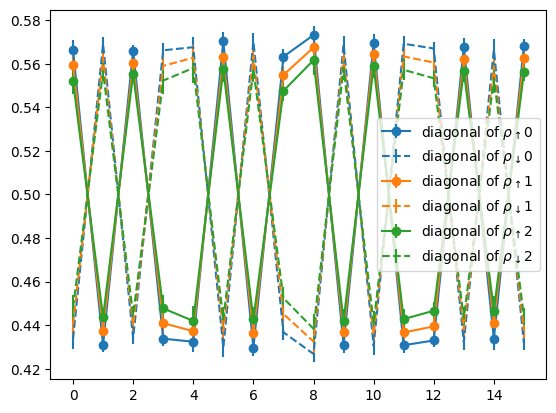

In [ ]:
%autoreload
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import matplotlib.pyplot as plt

from afqmctools.hamiltonian.converter import read_hamiltonian
from afqmctools.analysis.transform import hermitize_factory
from afqmctools.analysis.average import WALKER_TYPE,get_metadata,average_observable

SAIFRE_hdf5_output = fe_scratch_dir / "qmc.s003.stat.h5"
nspins = 1 # this is a noncollinear calculation, so one (combined) spin sector!
M = lattice.N_sites # get the number of sites to help with plotting

walker_type = WALKER_TYPE[get_metadata(SAIFRE_hdf5_output)["WalkerType"]]

# set up a transform the hermitize the one-rdm
hermitize = hermitize_factory(
    walker_type=walker_type
)

# get the metadata for plotting
metadata = get_metadata(SAIFRE_hdf5_output,"/Observables/BackPropagated/")
print(metadata)

bp_steps = metadata["BackPropSteps"]
naverages = metadata["NumAverages"]

print("BP steps", bp_steps)

# array to save one-rdm for each average
one_rdms = np.zeros((naverages,nspins,4*(M**2)),dtype=np.complex128)
one_rdms_err = np.zeros((naverages,nspins,4*(M**2)),dtype=np.complex128)

rho_ups = np.zeros((naverages,*lattice.L),dtype=np.complex128)
rho_downs = np.zeros((naverages,*lattice.L),dtype=np.complex128)

for avg in range(naverages):
    # Extract and Transform data
    one_rdms[avg],one_rdms_err[avg] = average_observable(
        SAIFRE_hdf5_output,
        eqlb=5,
        estimator='back_propagated',
        name="one_rdm",
        transform=[hermitize],
        ix=avg
    )

    # handle spin!!
    print(one_rdms[avg].shape)

    lattice_dims = lattice.L
    rho_diag = one_rdms[avg].reshape((2*M,2*M)).diagonal()
    rho_up = rho_diag[:M]#.reshape(lattice_dims)
    rho_down = rho_diag[M:]#.reshape(lattice_dims)

    rho_diag_err = one_rdms_err[avg].reshape((2*M,2*M)).diagonal()
    rho_up_err = rho_diag_err[:M]#.reshape(lattice_dims)
    rho_down_err = rho_diag_err[M:]#.reshape(lattice_dims)

    sites = np.arange(M)

    # add in constant energy for consistency with AuxilaryFields convention
    plt.errorbar(x=sites,y=rho_up.real,yerr=rho_up_err.real,fmt='-o',color=f"C{avg}",label=r"diagonal of $\rho_\uparrow$" + f"{avg}")
    plt.errorbar(x=sites,y=rho_down.real,yerr=rho_down_err.real,fmt='--',color=f"C{avg}",label=r"diagonal of $\rho_\downarrow$" + f"{avg}")

    # save density for visualizations below!
    rho_ups[avg] = rho_up.reshape(lattice_dims)
    rho_downs[avg] = rho_down.reshape(lattice_dims)


plt.legend()
plt.show()

## Visualing Observables on the Lattice

We used the `afqmctools.utils.visualize` module's `plot_lattice()` function earlier in order to visualize the lattice itself.
The same function allows us to colorize each lattice site based on some observables.
Below, we plot the charge density, then the spin density on the lattice.

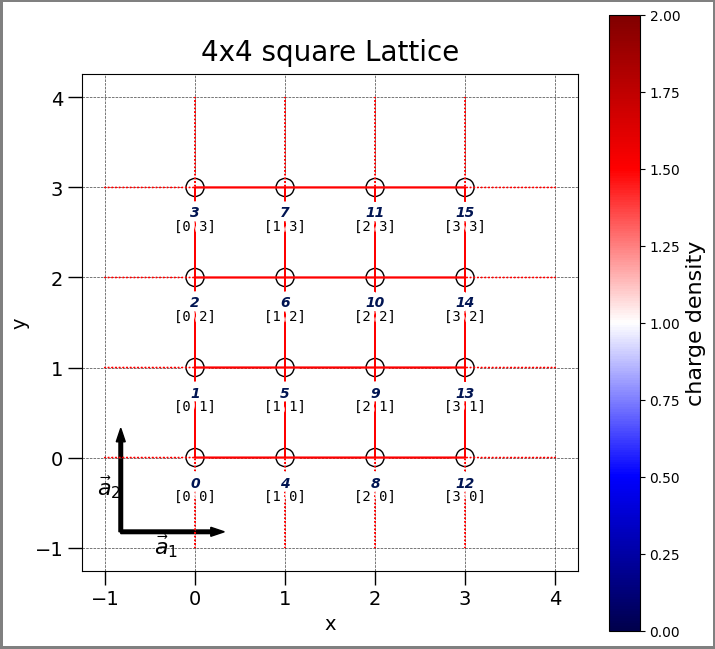

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': '4x4 square Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
import afqmctools.utils.visualize as vis

avg_to_plot = 2

rho_up = rho_ups[avg_to_plot]
rho_down = rho_downs[avg_to_plot]

rho_charge = rho_up + rho_down

vis.plot_lattice(
    lattice,
    density=rho_charge.real,
    density_label="charge density",
    vmin=0.0,
    vmax=2.0
)

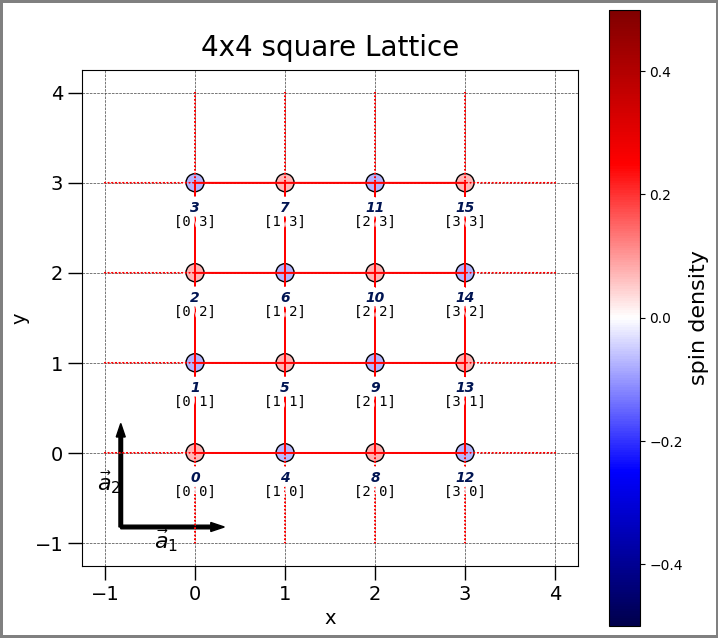

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': '4x4 square Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
import afqmctools.utils.visualize as vis

avg_to_plot = 1

rho_up = rho_ups[avg_to_plot]
rho_down = rho_downs[avg_to_plot]

rho_spin = 0.5*(rho_up - rho_down)

vis.plot_lattice(
    lattice,
    density=rho_spin.real,
    density_label="spin density",
    vmin=-0.5,
    vmax=0.5
)

# Old Material : 🚧 The following sections will be removed 🚧


### Analyzing the AFQMC one-rdm outpput

The one-rdm can be analyzed using the `afqmctools` python package.
Specifically, the `average_afqmc_rdm` function from the `afqmctools.analysis.rdm` module automates most of this.

A few features of `average_afqmc_rdm` are explained here for reference.

1. `average_afqmc_rdm()` will return the average one-rdm and the asociated stochastic errorbars. The shape of the returned one-rdm (and stochastic error matrix) is (number of "averges") x (number of independent spin sectors) x Nsites x Nsites. The meaning of the number of averages in explained above in the Section [multiple back propagation averages](#multiple-back-propagation-averages).

2. setting equilibraiton time, We can set Teq (in units of t^{-1} NOT steps!) to discard samples from the beginning of the measurement. Recall that we also set an equilibration length in the B.P. settings of the input file. The AFQMC code does not record the one-rdm for times less than the equilibration length. Therefore, the *effective* equilbration time becomes the sum of the equilibration length
set in the afqmc.json input file and Neq set here!  
```python
rho_avg, delta_rho = average_afqmc_rdm(Teq=1.2)
```  

***alternatively*** we can set $Neq$ to specify the equilbration time in measurement blocks. i.e. how many samples to throw out from the beginning of the calculation.

```python
rho_avg, delta_rho = average_afqmc_rdm(Neq=3)
```  


3. `average_afqmc_rdm` attempts to determine the autocorrelation length, $\kappa$, automatically; however, an autocorrelation length can also be specified as below. This can be used to test that automatically detected $\kappa$ value is correct - i.e. by repeating the averaging with different values of $\kappa$

```python
rho_avg, delta_rho = average_afqmc_rdm(kappa=3.0)
```  


Once we have an averaged one-rdm, we can use it compute various properties.
In this case, we will compute the charge-density and $\langle \hat{S}_z \rangle$.


In [ ]:
from afqmctools.analysis.rdm import average_afqmc_rdm


rho_avg, delta_rho = average_afqmc_rdm()

In [ ]:
# plot charge density

rho_total = (rho_avg[0,0].diagonal() + (rho_avg[0,1]).diagonal() ).reshape(lattice_dims)
delta_rho_total = np.sqrt(np.power(delta_rho[0,0],2) + np.power(delta_rho[0,1],2) ).diagonal().reshape(lattice_dims)

print(f"Integrated total number of electrons = {np.sum(rho_total)}")

fig,axs = plt.subplots(1,2,figsize=(12,8))

ax1 = axs[0]
ax1.set_title("charge density")
im = ax1.imshow(rho_total.real,cmap='seismic')
fig.colorbar(im,ax=ax1,cmap='seismic')


ax2 = axs[1]
im2 = ax2.imshow(delta_rho_total.real,cmap='seismic')
fig.colorbar(im2,ax=ax2,cmap='seismic')

ax2.set_title("delta charge density")


plt.show()


In [ ]:
# plot spin density
rho_spin_total = (rho_avg[0,0].diagonal() - (rho_avg[0,1]).diagonal() ).reshape(lattice_dims)
delta_rho_spin_total = np.sqrt(np.power(delta_rho[0,0],2) + np.power(delta_rho[0,1],2) ).diagonal().reshape(lattice_dims)

fig,axs = plt.subplots(1,2,figsize=(12,8))

print(rho_spin_total)

cmap = 'seismic'

ax1 = axs[0]
ax1.set_title("spin density")

im = ax1.imshow(rho_spin_total.real,cmap=cmap)
fig.colorbar(im,ax=ax1,cmap=cmap)


ax2 = axs[1]
im2 = ax2.imshow(delta_rho_spin_total.real,cmap=cmap)
fig.colorbar(im2,ax=ax2,cmap=cmap)

ax2.set_title("delta spin density")

plt.show()


In [ ]:
# analyze the energy - let's import this all here
!energy_stats qmc.s000.scalar.dat -x time -t -e 10.0 --savefig energy_hf.png

![image](./energy_hf.png)

and now the one-rdm...

In [ ]:
rho_avg, delta_rho = average_afqmc_rdm()

In [ ]:
# plot charge density

rho_total = (rho_avg[0,0].diagonal() + (rho_avg[0,1]).diagonal() ).reshape(lattice_dims)
delta_rho_total = np.sqrt(np.power(delta_rho[0,0],2) + np.power(delta_rho[0,1],2) ).diagonal().reshape(lattice_dims)

print(f"Integrated total number of electrons = {np.sum(rho_total)}")

fig,axs = plt.subplots(1,2,figsize=(12,8))

ax1 = axs[0]
ax1.set_title("charge density")
im = ax1.imshow(rho_total.real,cmap='seismic')
fig.colorbar(im,ax=ax1,cmap='seismic')


ax2 = axs[1]
im2 = ax2.imshow(delta_rho_total.real,cmap='seismic')
fig.colorbar(im2,ax=ax2,cmap='seismic')

ax2.set_title("delta charge density")

plt.show()

In [ ]:
# plot spin density
rho_spin_total = (rho_avg[0,0].diagonal() - (rho_avg[0,1]).diagonal() ).reshape(lattice_dims)
delta_rho_spin_total = np.sqrt(np.power(delta_rho[0,0],2) + np.power(delta_rho[0,1],2) ).diagonal().reshape(lattice_dims)

fig,axs = plt.subplots(1,2,figsize=(12,8))

print(rho_spin_total)

cmap = 'seismic'

ax1 = axs[0]
ax1.set_title("spin density")

im = ax1.imshow(rho_spin_total.real,cmap=cmap)
fig.colorbar(im,ax=ax1,cmap=cmap)


ax2 = axs[1]
im2 = ax2.imshow(delta_rho_spin_total.real,cmap=cmap)
fig.colorbar(im2,ax=ax2,cmap=cmap)

ax2.set_title("delta spin density")

plt.show()

## Final Exercise Notes

- we should choose a case where the free-electron / HF trial wavefunction comparison reverses. For low U, FE should work, but for large U, UHF is likely better.